In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path
from scipy.stats import gaussian_kde
import time

import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import zuko

import utils

### 1. NLL-based permutation importance

Write the context vector as $\mathbf{x} = (x_k, \mathbf{x}_{-k})$ where $x_k$ is the single feature of interest (say, `COV_URBAN`) and $\mathbf{x}_{-k} \in \mathbb{R}^{20}$ is everything else.

When you run:

```python
Xp[:, k] = Xp[torch.randperm(len(Xp)), k]
```

you are drawing $x_k^{(i)}$ values from its marginal ditribution and pairing them with the original $(\mathbf{x}_{-k}^{(i)}, \mathbf{y}^{(i)})$. The resulting dataset has samples distributed as:

$$(\tilde{x}_k^{(i)}, \mathbf{x}_{-k}^{(i)}, \mathbf{y}^{(i)}) \sim \tilde{P}$$

The permutation operation breaks **both** the conditional dependence $X_k \mid \mathbf{X}_{-k}$ and the direct relationship $X_k \to \mathbf{Y}$. The resulting distribution $\tilde{P}$ is one where:

$$X_k \perp (\mathbf{X}_{-k}, \mathbf{Y})$$

In the permuted world, $X_k$ has nothing to do with anything. It is pure noise.

To get final scores we analyse Model Reliance on feature $k$, i.e. $\text{MR}(k)$:
$$\text{MR}(k) = \mathcal{L}{\text{perm}}^{(k)} - \mathcal{L}{\text{orig}}.$$

In [33]:
def permutation_importance_full(flow, X, Y, feature_names, device, n=1000, n_repeats=15):
    """
    NLL-based permutation importance over ALL features.

    Uses n_repeats independent permutations to estimate mean and std.

    Parameters
    ----------
    flow       : trained zuko NSF
    X          : tensor of shape (N, n_feats) — standardized test features
    Y          : tensor of shape (N, n_target)       — standardized log-transformed targets
    feature_names : list of str, length n_feats
    device     : device on which we want to work
    n          : number of test samples to use
    n_repeats  : number of independent permutations per feature (Fisher et al. §3)

    Returns
    -------
    means : pd.Series  — mean NLL increase per feature
    stds  : pd.Series  — std of NLL increase (used for error bars)
    plots with error bars
    """
    # If Y is in the shape (N,) we transform in a matrix (N,1)
    if Y.ndim == 1:
        Y = Y.unsqueeze(-1)

    flow.eval()
    idx = torch.randperm(len(X))[:n]
    Xp = X[idx].clone()
    Yp = Y[idx]
    Xp = Xp.to(device)
    Yp = Yp.to(device)

    with torch.no_grad():
        base_nll = -flow(Xp).log_prob(Yp).mean().item()

    results = {}
    for k, feat in enumerate(feature_names):
        deltas = []
        for _ in range(n_repeats):
            Xp_perm = Xp.clone()
            # Independently permute only column k
            Xp_perm[:, k] = Xp[torch.randperm(len(Xp)), k]
            with torch.no_grad():
                perm_nll = -flow(Xp_perm).log_prob(Yp).mean().item()
            deltas.append(perm_nll - base_nll)
        results[feat] = (np.mean(deltas), np.std(deltas))

    means = pd.Series({k: v[0] for k, v in results.items()})
    stds  = pd.Series({k: v[1] for k, v in results.items()})

    # Plot with error bars
    order = means.sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(order.index, order.values,
            xerr=stds[order.index].values, capsize=4,
            color=['steelblue' if v > 0 else 'lightgray' for v in order.values])
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel("Mean ΔNLL", fontsize=11)
    ax.set_title("Permutation Feature Importance — All Context Features\n"
                 f"({n_repeats} permutation trials, error bars = ± std)", fontsize=12)
    plt.tight_layout()
    plt.show()
    return means, stds


### 2 Integrated gradient

### 3 Distribution-level importance

Normalizing flows are not canonical classifier, instead they produce a full distribution as model output not just point estimate.

Keeping this in mind we know that in a conditional NF, the context x parameterizes the entire flow transformation. The concept of "feature importance" must therefore be defined over the space of distributions, not scalar outputs. (this can be also extendend on how standard regression metrics (RMSE, R²) are inappropriate because they discard distributional information.)

We need so to define a metrics on two distribution $p$ and $q$: **The Jensen-Shannon divergence**:
$$JSD (p||q) = \frac{1}{2} KL(p||m) + \frac{1}{2} KL(q||m), \quad\text{where }m=\frac{p+1}{2}.$$

It is bounded in $[0, 1]$, symmetric, and defined even when $p$ and $Q$ do not share the same support (unlike plain $KL$ divergence). This makes it ideal for comparing empirical distributions from Monte Carlo samples.

In [34]:
from scipy.spatial.distance import jensenshannon

def distributional_importance(flow, X, feature_names, device, n_context=150, n_samples=1000):
    """
    Distribution-level feature importance via Jensen-Shannon divergence.
    
    For each feature k, measures how much the predicted distribution
    p(y | x) changes when x_k is replaced by its standardized mean (0).
    This method is unique to density models and reveals which features
    most change the shape of the conditional distribution.
    
    Parameters
    ----------
    flow          : trained zuko NSF (in eval mode)
    X             : tensor of shape (N, n_feats) — standardized test features
    feature_names : list of str, length n_feats
    device        : device on which to run computations
    n_context     : number of test contexts to average over
    n_samples     : number of Monte Carlo samples per distribution
    
    Returns
    -------
    combined   : pd.Series — sum of DAMAGES + CASUALTIES JSD²
    damages    : pd.Series — JSD² for DAMAGES marginal only
    casualties : pd.Series — JSD² for CASUALTIES marginal only
    plots with three panels showing importance for each target separately
    
    """
    flow.eval()
    idx = torch.randperm(len(X))[:n_context]
    Xs = X[idx].to(device)
    
    n_targets = 2  # DAMAGES, CASUALTIES
    n_features = len(feature_names)
    all_js_values = torch.zeros(n_features, n_targets, n_context, device=device)
    
    for k, feat in enumerate(feature_names):
        # Sample from original distributions for all contexts at once
        with torch.no_grad():
            s_orig_all = flow(Xs).sample((n_samples,)).squeeze(-2)
        
        # Create masked contexts
        Xs_masked = Xs.clone()
        Xs_masked[:, k] = 0.0
        
        with torch.no_grad():
            s_mask_all = flow(Xs_masked).sample((n_samples,)).squeeze(-2)
        
        # Compute JSD for each context
        for i in range(n_context):
            s_orig = s_orig_all[:, i, :]  # (n_samples, n_targets)
            s_mask = s_mask_all[:, i, :]
            
            for dim_idx in range(n_targets):
                orig_vals = s_orig[:, dim_idx].cpu().numpy()
                mask_vals = s_mask[:, dim_idx].cpu().numpy()
                
                all_vals = np.concatenate([orig_vals, mask_vals])
                bins = np.linspace(np.percentile(all_vals, 1),
                                   np.percentile(all_vals, 99), 60)
                
                p, _ = np.histogram(orig_vals, bins=bins, density=True)
                q, _ = np.histogram(mask_vals, bins=bins, density=True)
                
                p = p + 1e-10; q = q + 1e-10
                p /= p.sum(); q /= q.sum()
                
                js = jensenshannon(p, q) ** 2
                all_js_values[k, dim_idx, i] = js
    
    # Aggregate results
    js_mean = all_js_values.mean(dim=2).cpu().numpy()
    
    results = {}
    for k, feat in enumerate(feature_names):
        results[feat] = {
            'damages': js_mean[k, 0],
            'casualties': js_mean[k, 1],
            'combined': js_mean[k, 0] + js_mean[k, 1]
        }
    
    combined   = pd.Series({f: v['combined'] for f, v in results.items()}).sort_values()
    damages    = pd.Series({f: v['damages'] for f, v in results.items()})
    casualties = pd.Series({f: v['casualties'] for f, v in results.items()})
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))
    for ax, s, title in zip(axes,
                             [combined.sort_values(),
                              damages.reindex(combined.index),
                              casualties.reindex(combined.index)],
                             ['Combined (DAMAGES + CASUALTIES)',
                              'DAMAGES only', 'CASUALTIES only']):
        ax.barh(s.index, s.values, color='teal', alpha=0.8)
        ax.set_xlabel("Mean JSD²", fontsize=10)
        ax.set_title(title, fontsize=11)
    
    plt.suptitle("Distributional Feature Importance (Jensen-Shannon Divergence)", 
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()
    
    return combined, damages, casualties

### Load the main dataset

In [35]:
DATASET_PATH = Path("../datasets/disasters_merged_all_feats.csv")

In [36]:
df0 = pd.read_csv(DATASET_PATH)

In [37]:
event_group_dfs = {
    'Hail': df0[df0['EVENT_GROUP'] == 'Hail'].drop(columns=['EVENT_GROUP', 'WIND_SPEED']),
    'Wind': df0[df0['EVENT_GROUP'] == 'Wind'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Storm': df0[df0['EVENT_GROUP'] == 'Storm'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Flood': df0[df0['EVENT_GROUP'] == 'Flood'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Freeze': df0[df0['EVENT_GROUP'] == 'Freeze'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Drought': df0[df0['EVENT_GROUP'] == 'Drought'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Snow': df0[df0['EVENT_GROUP'] == 'Snow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heat': df0[df0['EVENT_GROUP'] == 'Heat'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Heavy Rain': df0[df0['EVENT_GROUP'] == 'Heavy Rain'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Fog': df0[df0['EVENT_GROUP'] == 'Fog'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Wildfire': df0[df0['EVENT_GROUP'] == 'Wildfire'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Lightning': df0[df0['EVENT_GROUP'] == 'Lightning'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Debris Flow': df0[df0['EVENT_GROUP'] == 'Debris Flow'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
    'Avalanche': df0[df0['EVENT_GROUP'] == 'Avalanche'].drop(columns=['EVENT_GROUP', 'HAIL_SIZE']),
}

In [38]:
TARGET_COLS = ["DAMAGES", "CASUALTIES"]

X_COLS = [
    'BEGIN_LAT', 'BEGIN_LON',
    'DURATION_HOURS', 'WIND_SPEED', # change with hail size for hail
    'TIME_DAY_SIN', 'TIME_DAY_COS', 'TIME_YEAR_NORM',
    'PRECIPITATION', 'TMIN', 'TMAX',
    'ELEVATION', 'SLOPE',
    'COV_BARREN', 'COV_CULTIVATED', 'COV_VEGETATION',
    'COV_FOREST', 'COV_WATER', 'COV_SNOW_ICE', 'COV_URBAN',
    'RIVER_DISTANCE', 'SEA_DISTANCE'
]

### Create the model just once

In [39]:
EPOCHS = 200
LEARNING_RATE = 1e-3
BATCH_SIZE = 256
X_DIM = len(X_COLS)
Y_DIM = len(TARGET_COLS)   # DAMAGES, CASUALITIES

flow = zuko.flows.NSF(
    features=Y_DIM,
    context=X_DIM,
    transforms=8,
    hidden_features=[256, 256, 256],
    bins=16
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 1295088 parameters


# Flood

Model moved to cuda


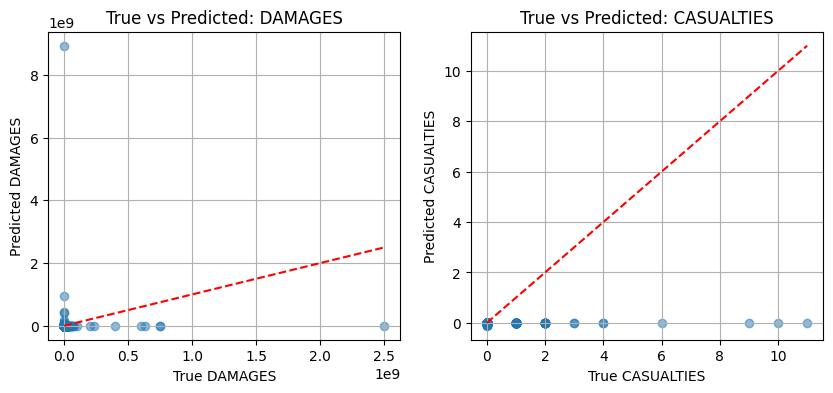

In [40]:
EVENT_GROUP = 'Flood'
RUN_PATH = Path(f"../runs/flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

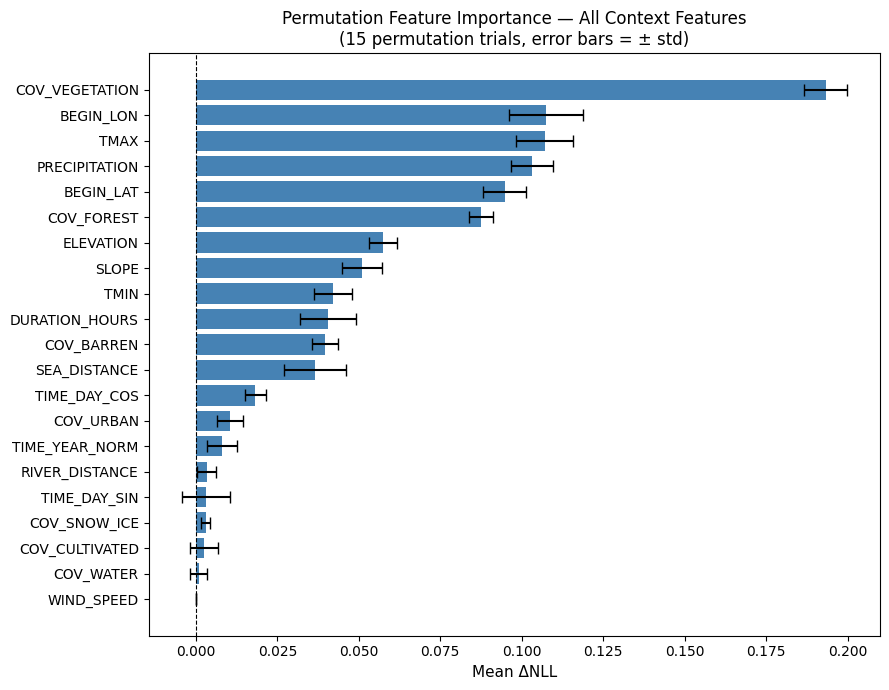

In [41]:
flood_means, flood_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

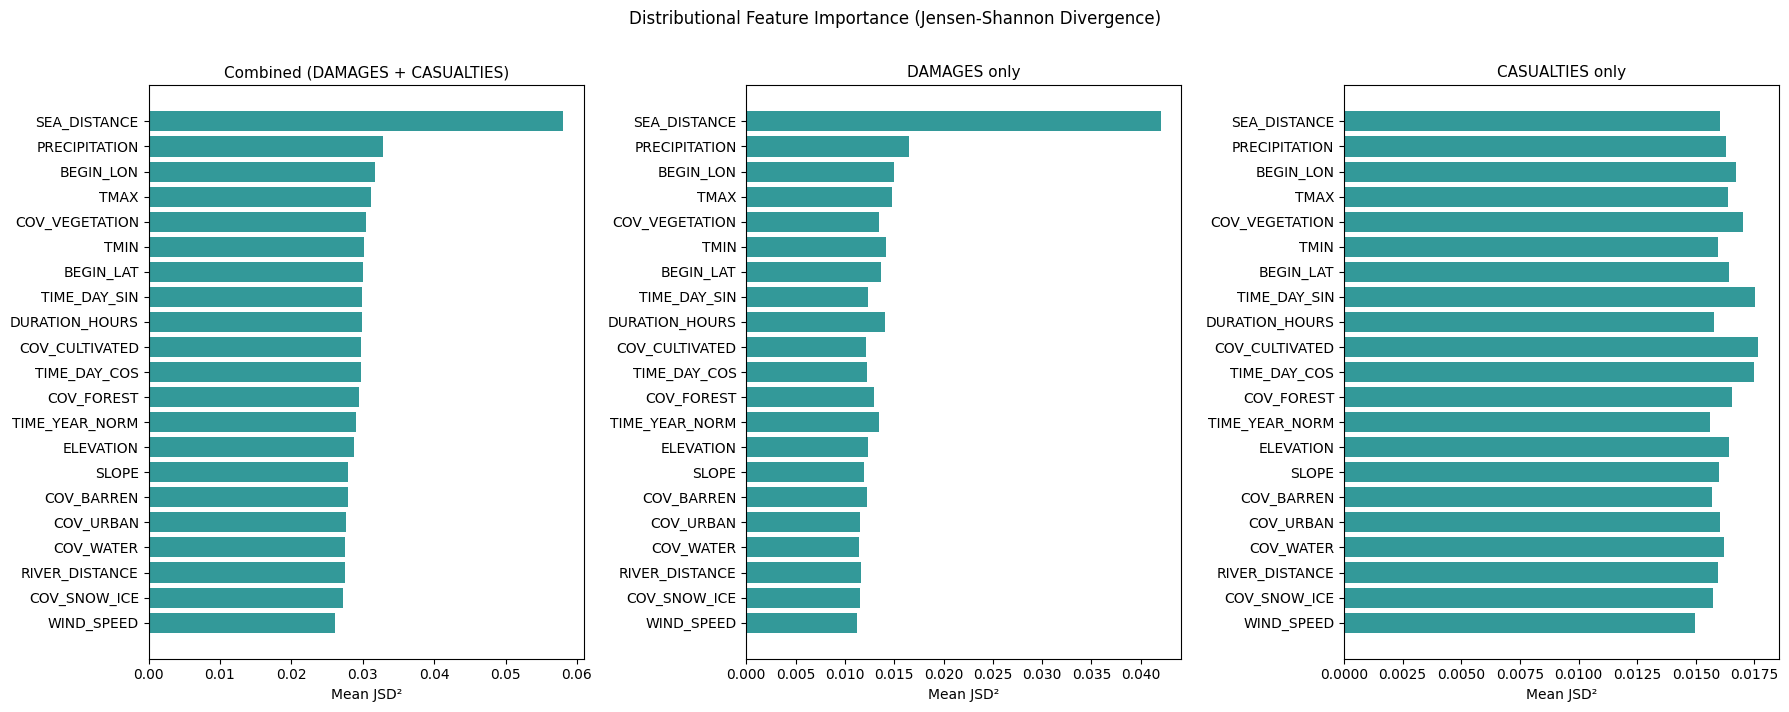

In [42]:
flood_JSD_targets, flood_JSD_damages, flood_JSD_casualities = distributional_importance(flow, X_test, X_COLS, device)

# Storm

Model moved to cuda


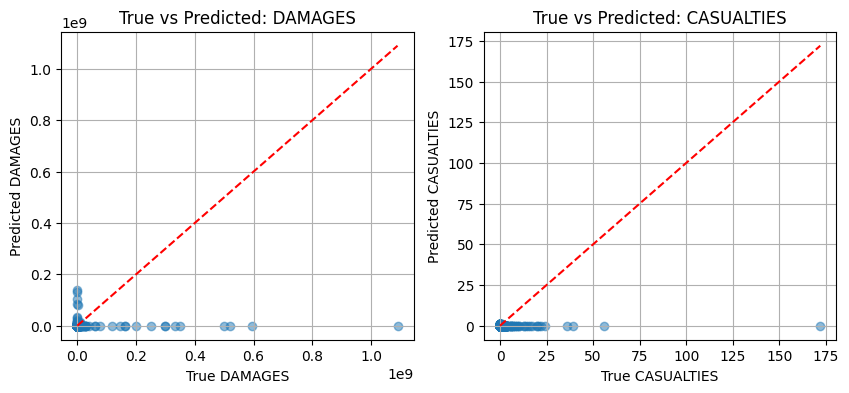

In [43]:
EVENT_GROUP = 'Storm'
RUN_PATH = Path(f"../runs/best_flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

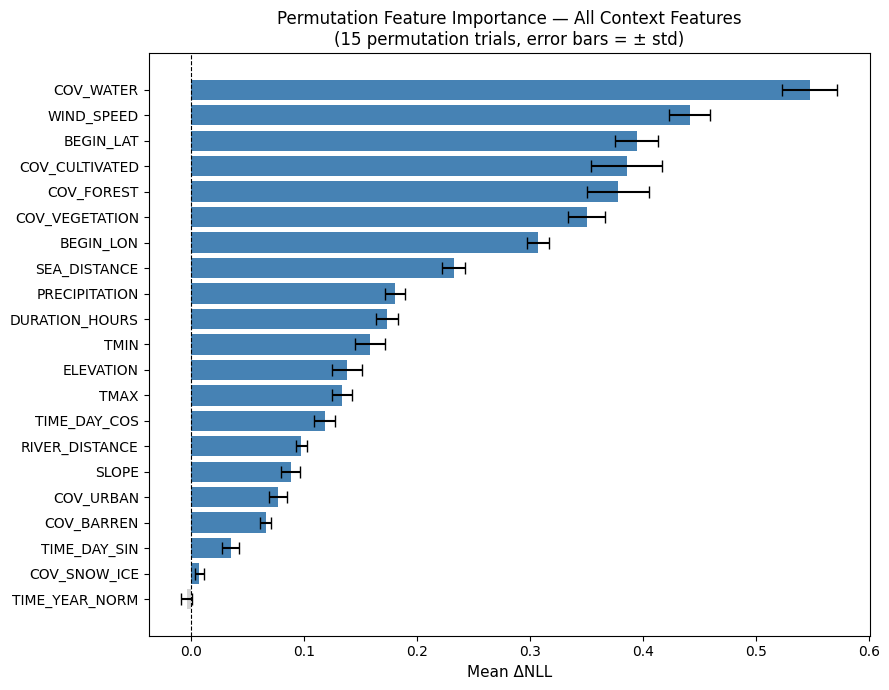

In [44]:
storm_means, storm_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

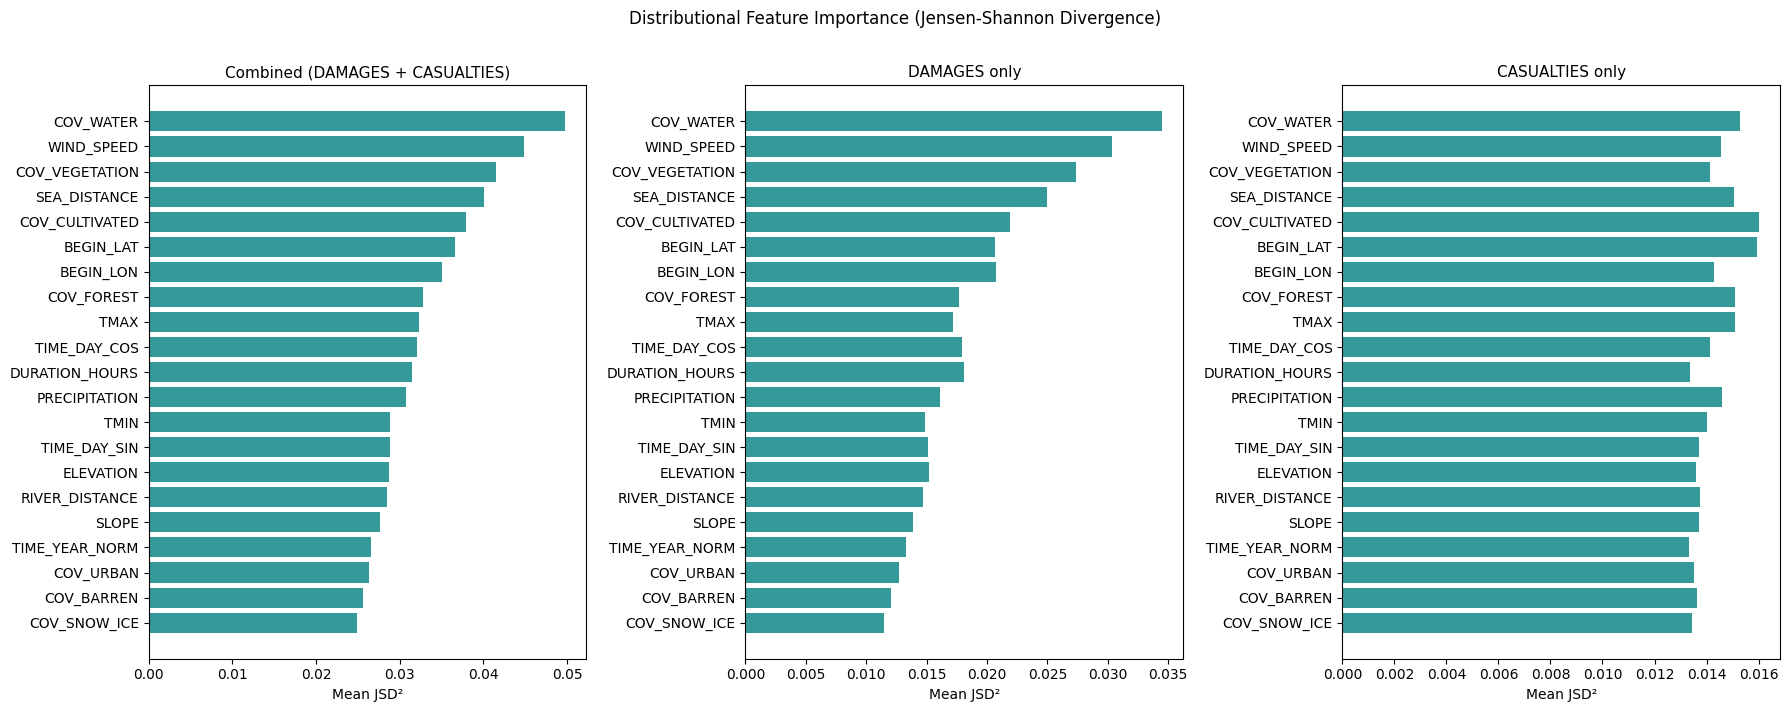

In [45]:
_,_,_ = distributional_importance(flow, X_test, X_COLS, device)

# Drought

Model moved to cuda


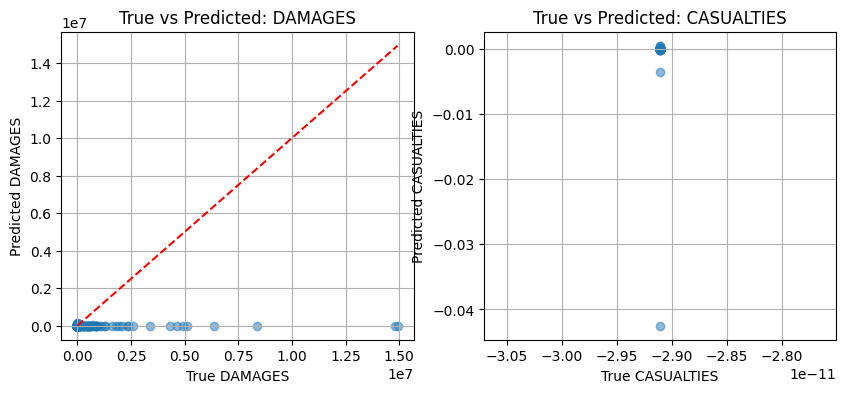

In [46]:
EVENT_GROUP = 'Drought'
RUN_PATH = Path(f"../runs/best_flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

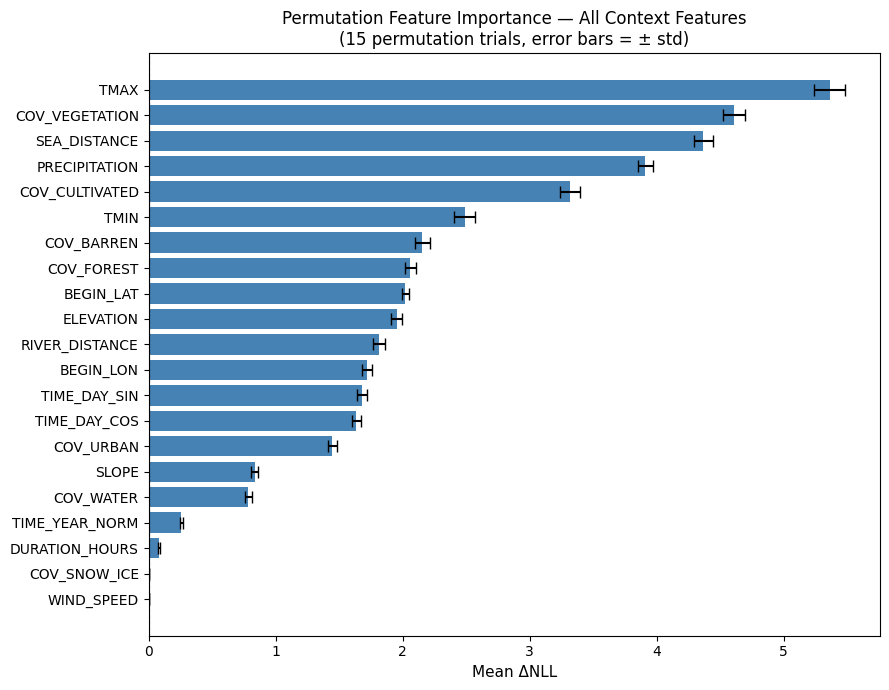

In [47]:
drought_means, drought_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

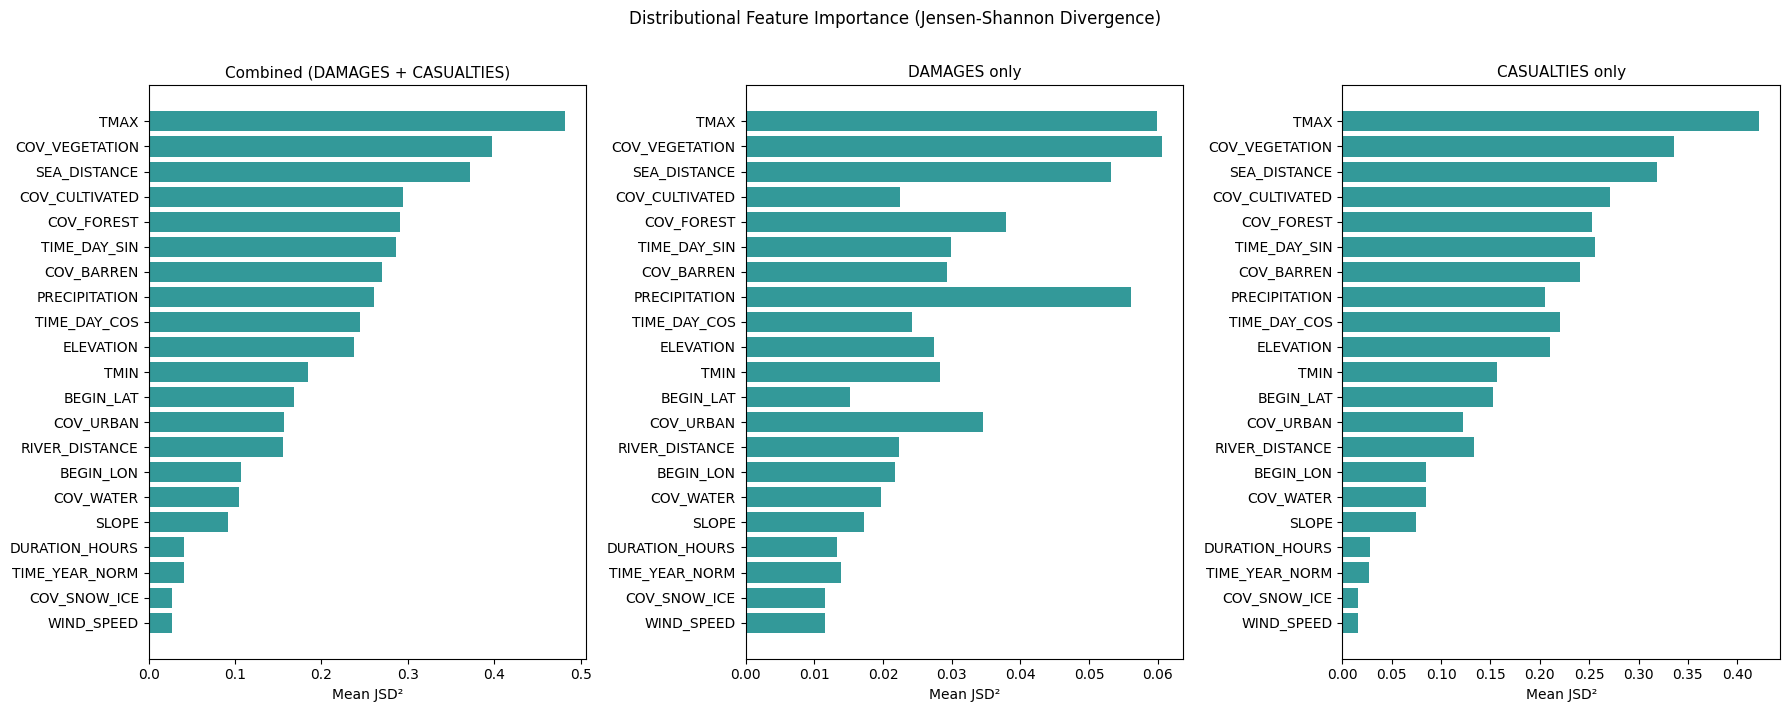

In [48]:
_,_,_ = distributional_importance(flow, X_test, X_COLS, device)

# Wildfire

Model moved to cuda


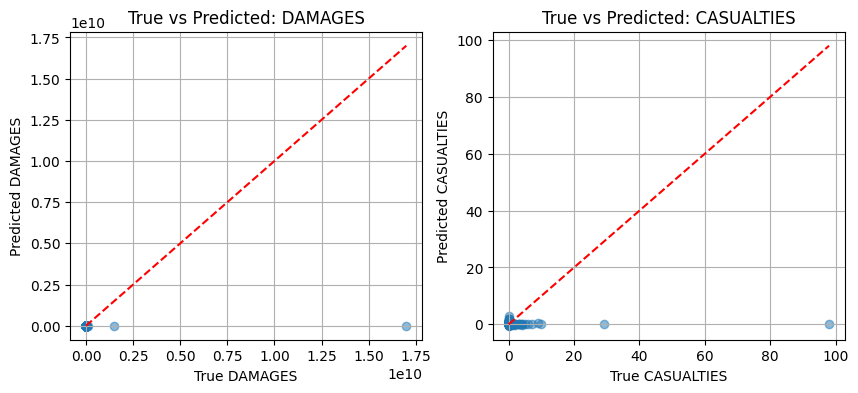

In [50]:
EVENT_GROUP = 'Wildfire'
RUN_PATH = Path(f"../runs/flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

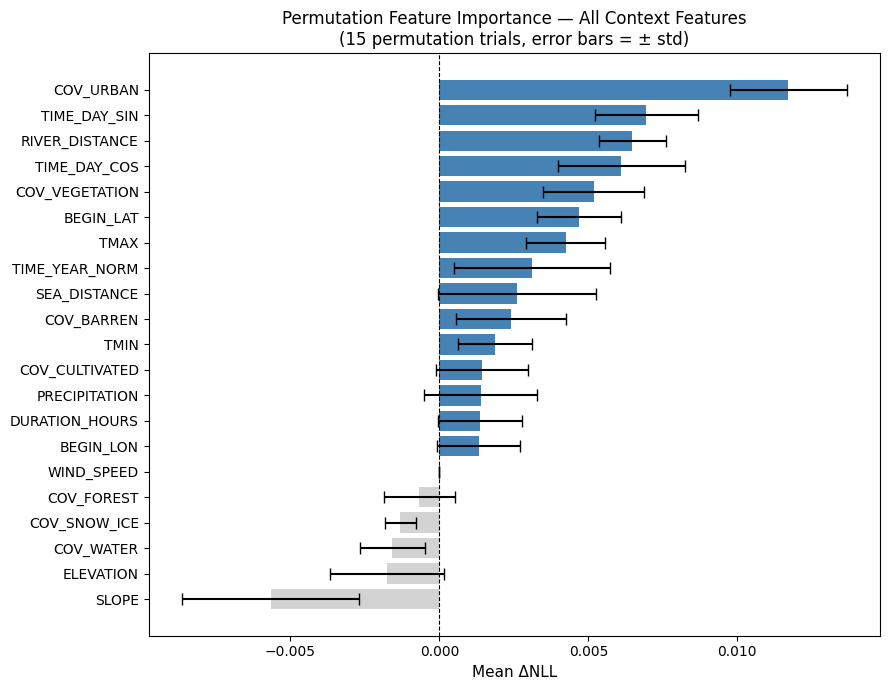

In [51]:
wildfire_means, wildfire_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

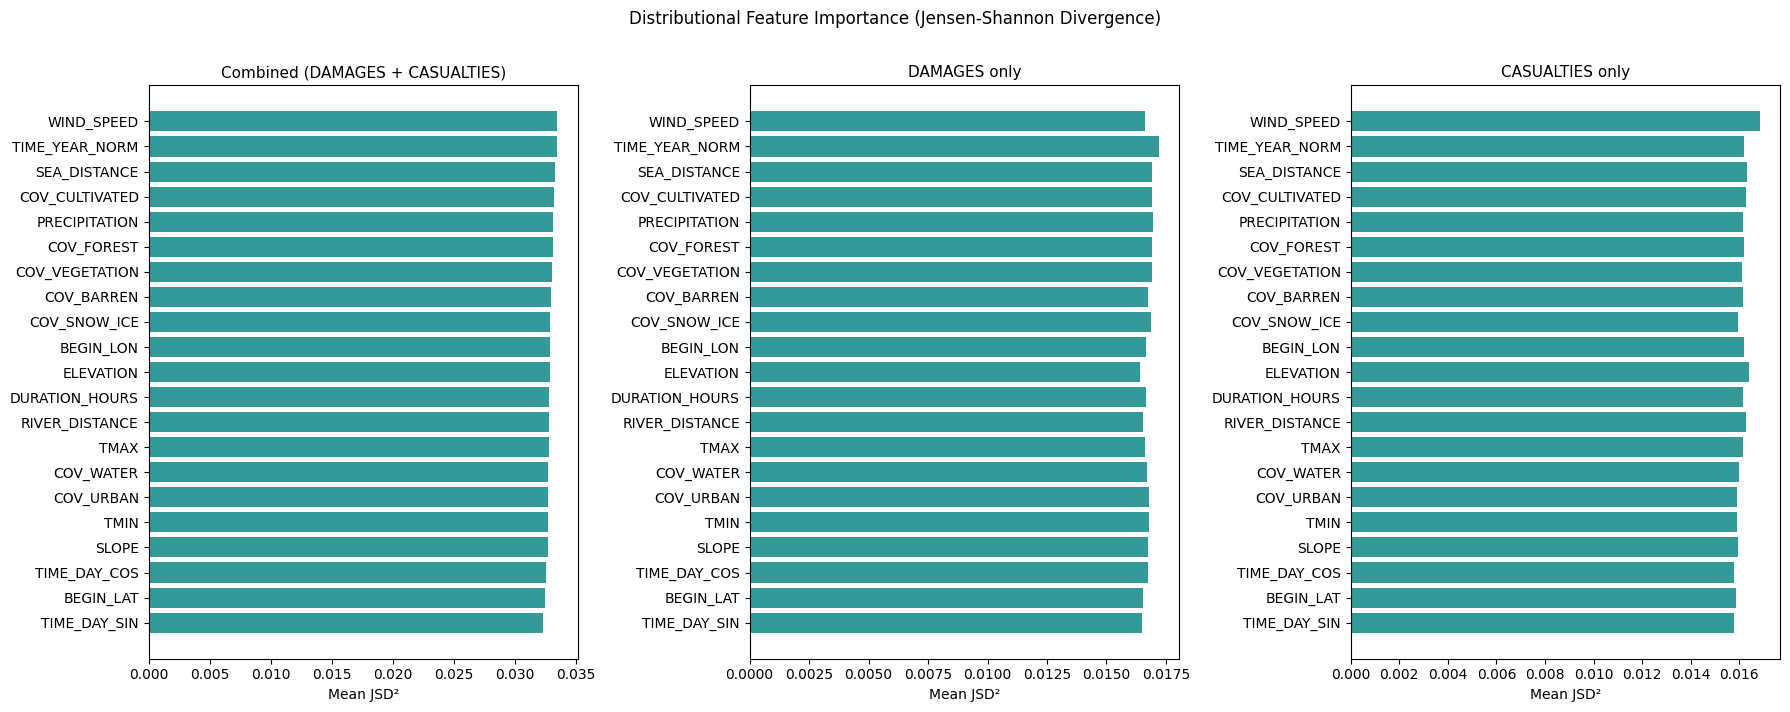

In [52]:
_,_,_ = distributional_importance(flow, X_test, X_COLS, device)

# Avalanche

Model moved to cuda


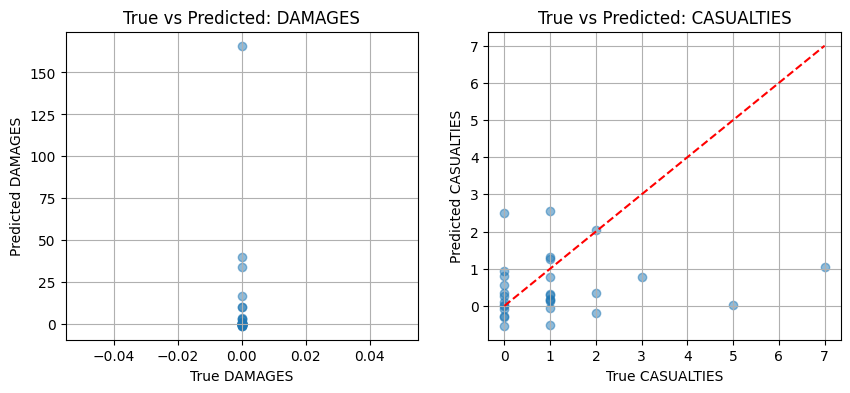

In [67]:
EVENT_GROUP = 'Avalanche'
RUN_PATH = Path(f"../runs/flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

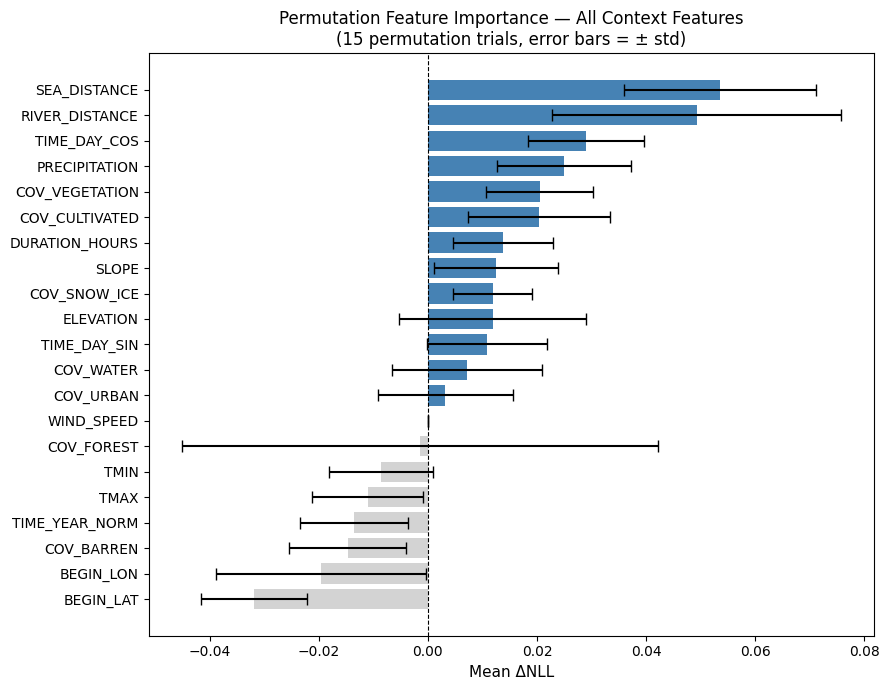

In [68]:
avalanche_means, avalanche_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

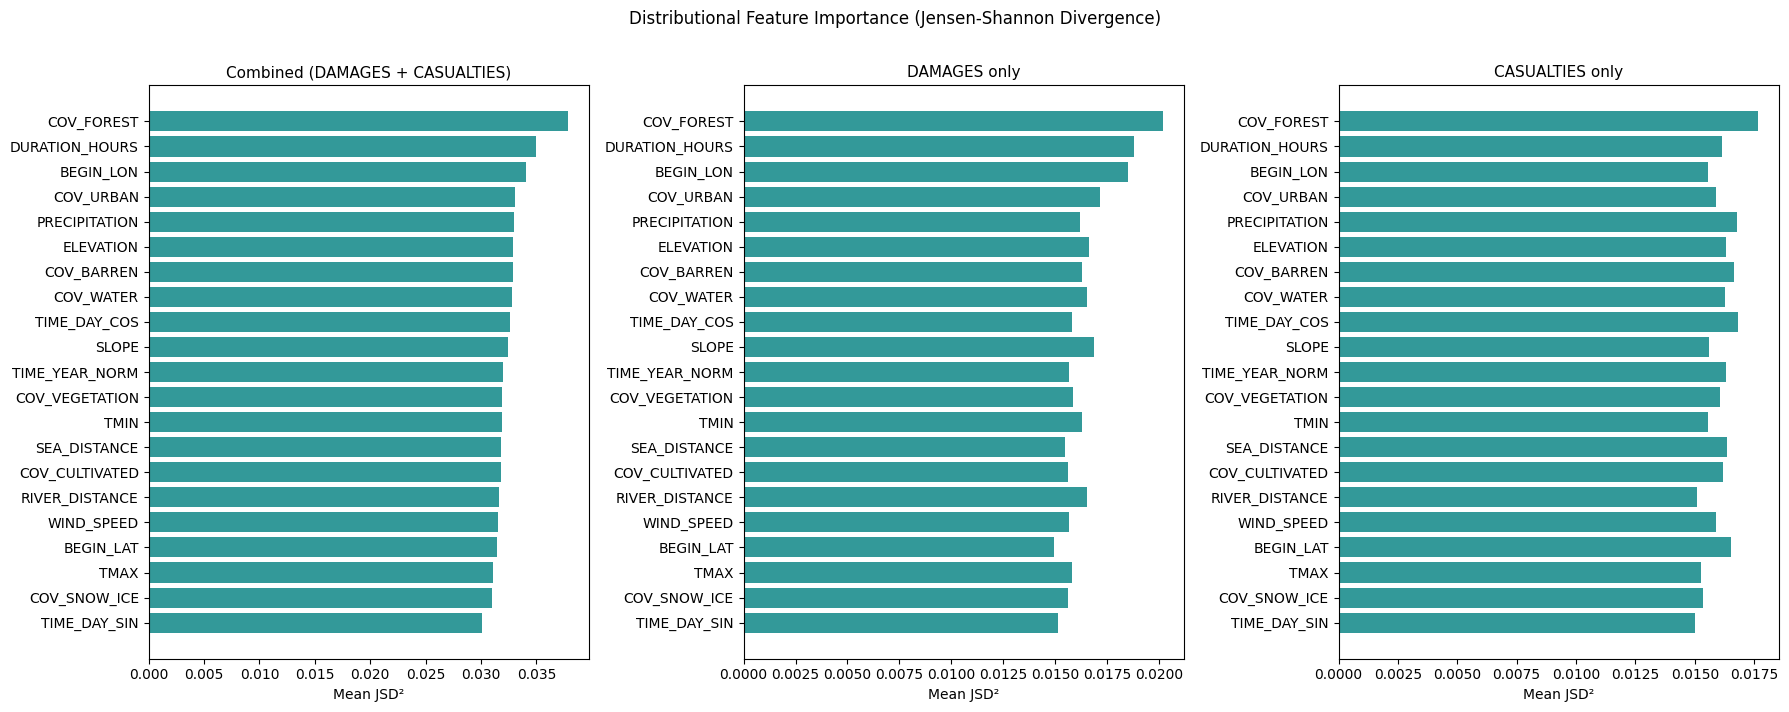

In [71]:
_,_,_ = distributional_importance(flow, X_test, X_COLS, device, n_context=len(X_test))

# Freeze

Model moved to cuda


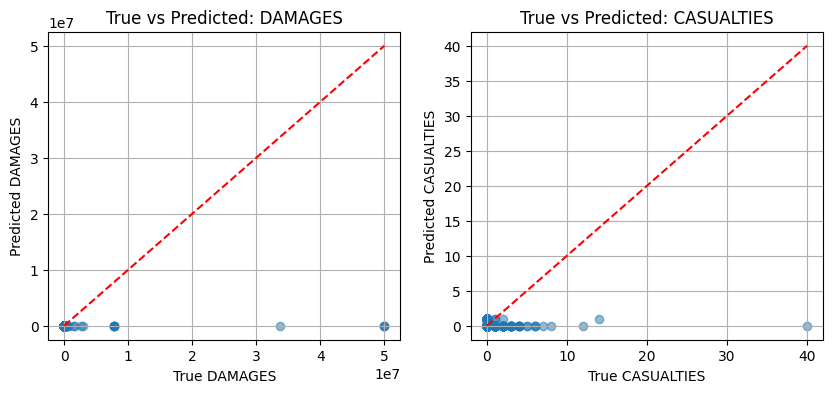

In [61]:
EVENT_GROUP = 'Freeze'
RUN_PATH = Path(f"../runs/best_flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

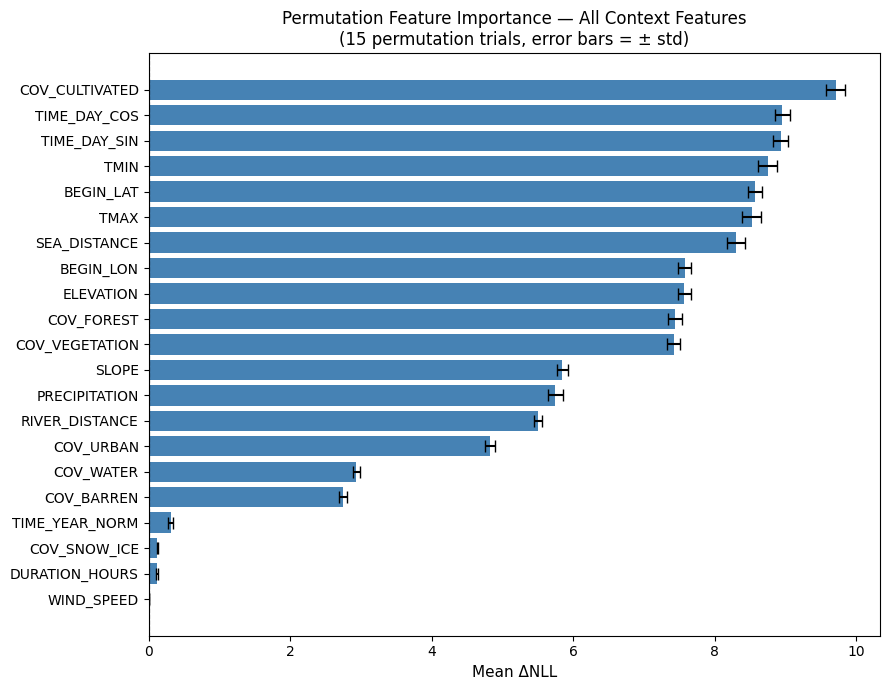

In [62]:
freeze_means, freeze_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

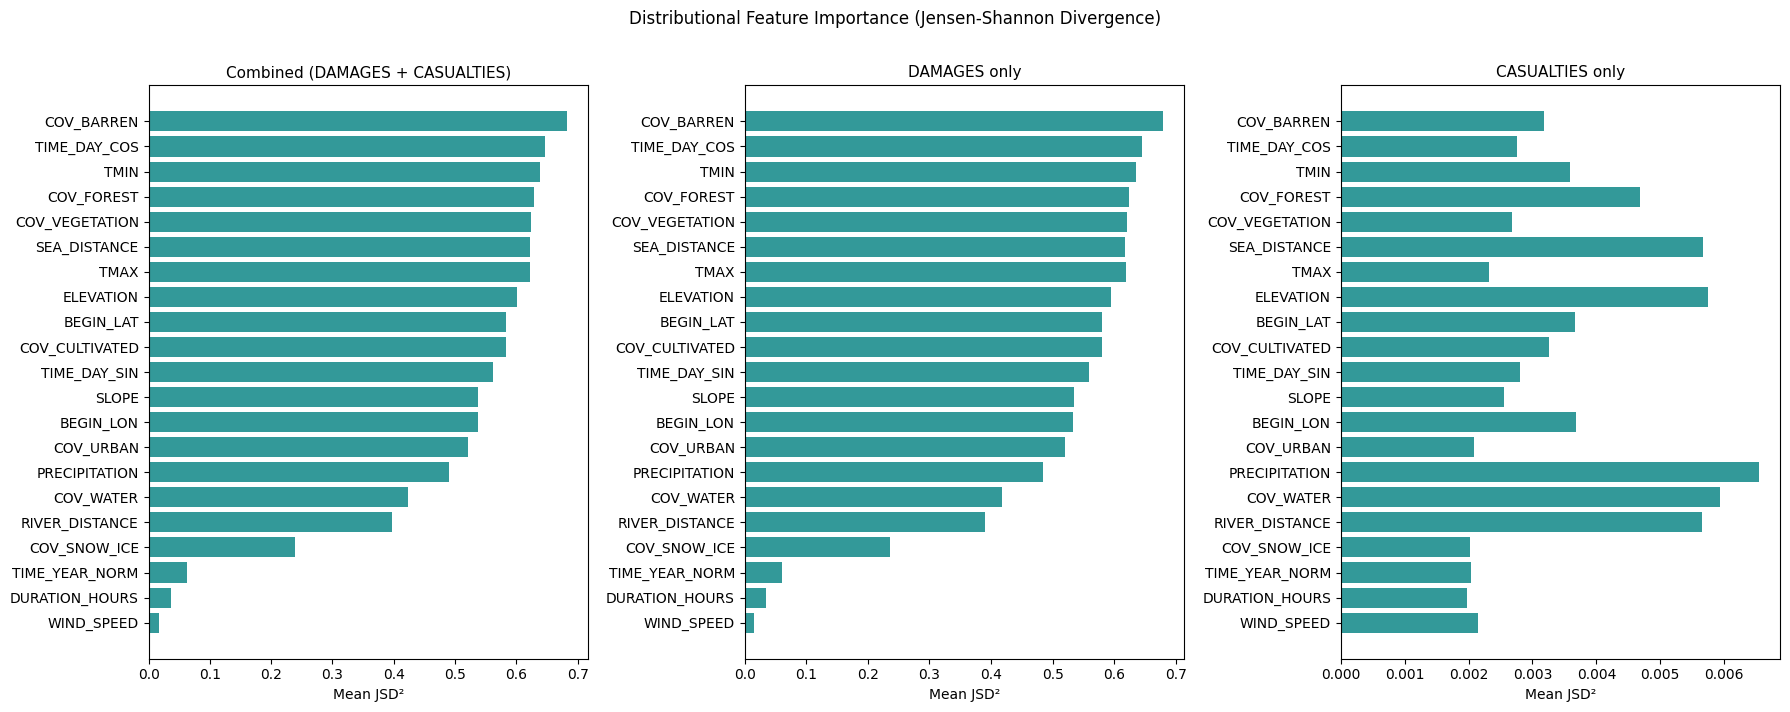

In [63]:
_,_,_ = distributional_importance(flow, X_test, X_COLS, device)

# Heat

Model moved to cuda


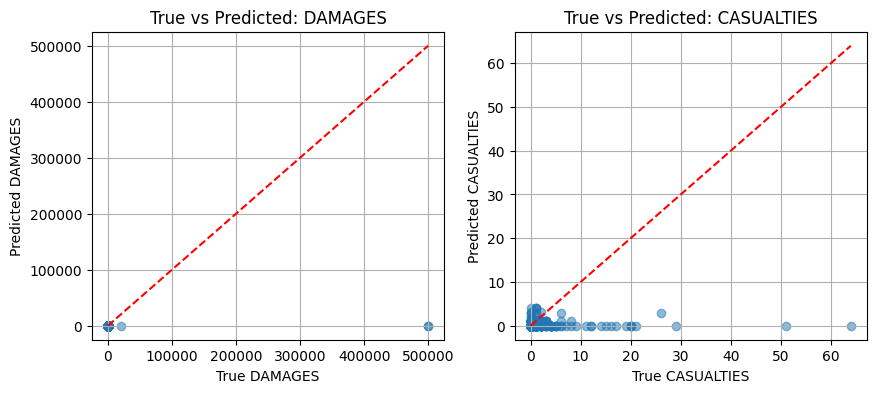

In [64]:
EVENT_GROUP = 'Heat'
RUN_PATH = Path(f"../runs/best_flow_{EVENT_GROUP.lower()}.pt")

df = event_group_dfs[EVENT_GROUP]

X = df[X_COLS].values.astype(np.float32)
Y = df[TARGET_COLS].values.astype(np.float32)

# targets log transformation
Y = np.log1p(Y)

# train-val-test split
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.3, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# standardize features and targets
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_val   = x_scaler.transform(X_val)
X_test  = x_scaler.transform(X_test)

Y_train = y_scaler.fit_transform(Y_train)
Y_val   = y_scaler.transform(Y_val)
Y_test  = y_scaler.transform(Y_test)

# conversion to tensors
X_train = torch.tensor(X_train)
Y_train = torch.tensor(Y_train)

X_val = torch.tensor(X_val)
Y_val = torch.tensor(Y_val)

X_test = torch.tensor(X_test)
Y_test = torch.tensor(Y_test)

# data loaders
train_ds = TensorDataset(X_train, Y_train)
val_ds   = TensorDataset(X_val, Y_val)
test_ds   = TensorDataset(X_val, Y_val)
test_loader= DataLoader(test_ds, batch_size=BATCH_SIZE)

# Load model weights
flow.load_state_dict(torch.load(RUN_PATH, weights_only=True))
flow.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
flow = flow.to(device)
print(f"Model moved to {device}")

# Print prediction vs ground truth
utils.run_inference_and_plot(flow, test_loader, y_scaler, TARGET_COLS, device)

## Feature importance analysis

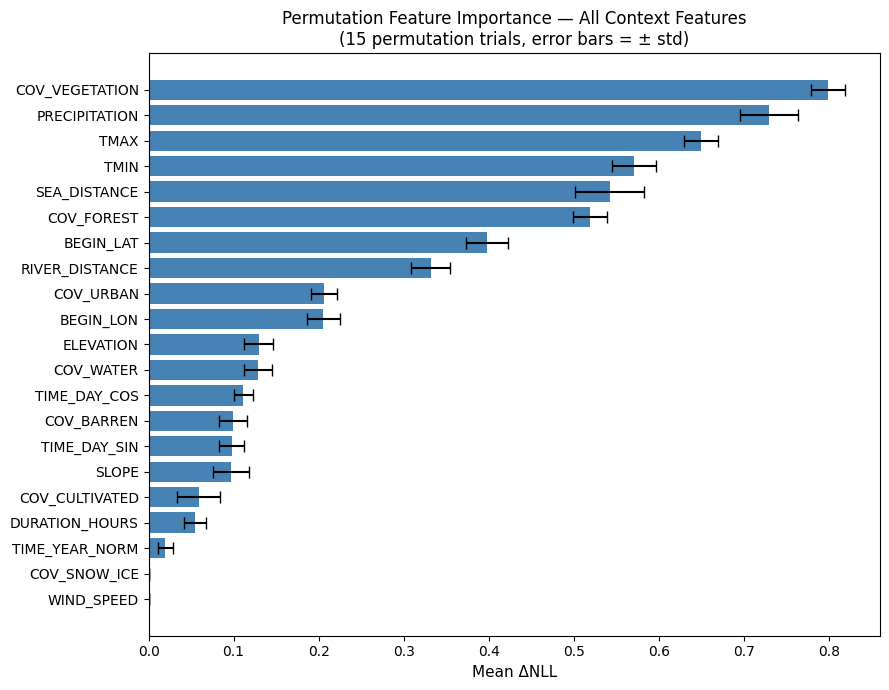

In [65]:
heat_means, heat_stds = permutation_importance_full(flow, X_test, Y_test, X_COLS, device)

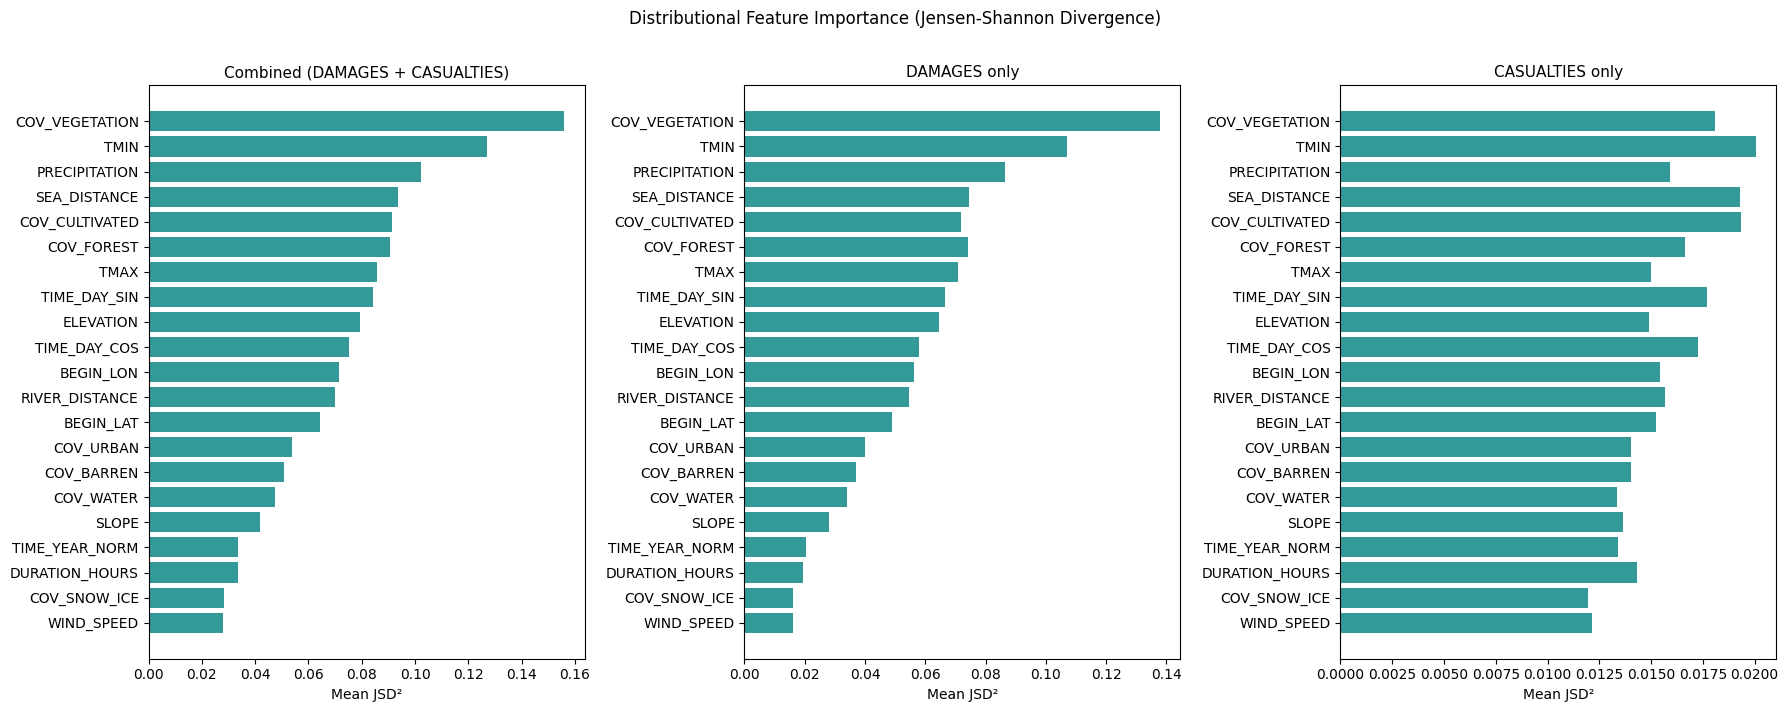

In [66]:
_,_,_ = distributional_importance(flow, X_test, X_COLS, device)